# Assignment 2: Privacy Attacks
#### Maxwell Heefner
#### ECE209AS
#### Assignment 2
#### 2 March 26

## **Overview**
 The goal of this assignment is to introduce students to the concepts of trustworthy machine learning with a focus on the privacy attacks. This assignment is broken into 2 parts. (1) Part 1 involves conducting membership inference attacks against machine learning models. (2) Part 2 involves answering questions about privacy attacks. We will provide demonstrations for students to work on the assignment with solution submission to Gradescope. We ask that students not attempt to perform out of scope attacks that attack the grading infrastructure such as DDoS attacks or exfiltrating non-publicly released assignment components. It is recommended that students develop and test exploits locally first before submitting to the autograder. However, we encourage students to find bugs and issues with the assignment application ! If students identify any additional vulnerabilities in the application, please privately message the course instructors. 😀

## **Part 1.** 
Membership Inference Attacks The first part of this assignment involves conducting membership inference attacks ( https://arxiv.org/pdf/1610.05820.pdf ) against machine learning models. You are supposed to train a classifier (called target classifier) and then perform membership inference attacks on it. For simplicity, we provide exemplar code implementations for your reference (See Materials) . You are free to choose the task to attack (either CIFAR10 or Nursery) and build your attack following the provided codebase. Your goal is to explore different settings of membership inference attack with your codebase.
- **Note:** Nursery was chosen for this assignment

In [1]:
# Setup
import torch
import os
import random
import numpy as np
import sys

# Art module not found when run on NVIDIA RTX PRO 6000 
!pip -q install adversarial-robustness-toolbox scikit-learn matplotlib pandas

sys.path.insert(0, os.path.abspath('..'))

SEED = 209 # Because ECE209
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print('Torch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.1 MB/s eta 0:00:0000:010:01
Torch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [2]:
# Load Data
from art.utils import load_nursery
from sklearn.ensemble import RandomForestClassifier

(x_train, y_train), (x_test, y_test), _, _ = load_nursery(test_set=0.5)



In [3]:
# Sanity Check
print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)

target = RandomForestClassifier(random_state=SEED, n_estimators=50)
target.fit(x_train, y_train)

train_acc = target.score(x_train, y_train)
test_acc = target.score(x_test, y_test)

print(f"Sanity Train Accuracy: {train_acc:.4f}")
print(f"Sanity Test Accuracy:  {test_acc:.4f}")

Train shape: (6478, 24) (6478,)
Test shape: (6478, 24) (6478,)
Sanity Train Accuracy: 1.0000
Sanity Test Accuracy:  0.9756


In [ ]:
# Model Config

# Target Model
TARGET_MODEL_TYPE = "RandomForest"

# Data Split
TEST_SET_RATIO = 0.5 # From the nursery dataset
ATTACK_TRAIN_RATIO = 0.5 # Ratio of attack training data to total data

# Shadow Model
SHADOW_MODEL_TYPE = "RandomForest"
ATTACK_MODEL_TYPE = "RandomForest"
SHADOW_MODEL_COUNT = 4


### **Q1.** 
Train a target classifier (target classifier is the model we aim to attack). Please specify what’s the task, what’s the size of the training dataset, what’s the model architecture and what’s the clean accuracy. For simplicity, you can use the default setting of the codebase.

In [5]:
# Q1 - Train Target Classifier
from art.estimators.classification.scikitlearn import ScikitlearnRandomForestClassifier

# Default target model used in original project (/attack_membership_inference.ipynb)
target_model = RandomForestClassifier()
target_model.fit(x_train, y_train)

# ART wrapper 
art_target_classifier = ScikitlearnRandomForestClassifier(target_model)

# Clean  metrics
target_train_acc = target_model.score(x_train, y_train)
target_test_acc = target_model.score(x_test, y_test)

# Q1 info
q1_train_size = len(x_train)
q1_model = 'RandomForestClassifier() with default sklearn settings'

print(f"Base model test accuracy: {target_test_acc:.4f}")


Base model test accuracy: 0.9753


### **Q1 Results**

In [6]:
# Q1 Results
print('Task:', 'Multiclass classification on Nursery application outcomes')
print('Training Set Size:', q1_train_size)
print('Model:', q1_model)
print(f"Clean Accuracy (Train/Test): {target_train_acc:.4f} / {target_test_acc:.4f}")


Task: Multiclass classification on Nursery application outcomes
Training Set Size: 6478
Model: RandomForestClassifier() with default sklearn settings
Clean Accuracy (Train/Test): 1.0000 / 0.9753


### **Q2.**
Implement shadow model based membership inference attacks against your classifier. Please see Materials for details. Please specify what’s the size of the shadow dataset, how many shadow models you have trained, what’s the member or nonmember data points for evaluation and what’s the precision/recall/AUROC of your attack. For simplicity, you can use the default setting of the codebase.

In [ ]:
# Q2 - Shadow Model Membership Inference Attack
from art.attacks.inference.membership_inference import ShadowModels, MembershipInferenceBlackBox
from art.attacks.inference.membership_inference import MembershipInferenceBlackBoxRuleBased
from art.utils import to_categorical
from sklearn.metrics import roc_auc_score

# Shadow data
x_shadow, y_shadow = x_test, y_test
num_classes = len(np.unique(y_train))

print(f"Shadow Dataset Size: {len(x_shadow)}")
print(f"Q1 Target Clean Test Accuracy: {target_test_acc:.4f}")

# Train shadow models
shadow_models = ShadowModels(art_target_classifier, num_shadow_models=SHADOW_MODEL_COUNT)
(member_x, member_y, member_predictions), (nonmember_x, nonmember_y, nonmember_predictions) = shadow_models.generate_shadow_dataset(
    x_shadow, to_categorical(y_shadow, num_classes)
)

shadow_scores = [sm.model.score(x_test, y_test) for sm in shadow_models.get_shadow_models()]
print("Shadow model accuracies on x_test:", [round(v, 4) for v in shadow_scores])

# Train black-box attack model from shadow outputs
attack = MembershipInferenceBlackBox(art_target_classifier, attack_model_type='rf')
attack.fit(member_x, member_y, nonmember_x, nonmember_y, member_predictions, nonmember_predictions)

# Evaluate on Q1 target members/non-members
member_infer = attack.infer(x_train, y_train)
nonmember_infer = attack.infer(x_test, y_test)

member_acc = np.sum(member_infer) / len(x_train)
nonmember_acc = 1 - np.sum(nonmember_infer) / len(x_test)
attack_acc = (member_acc * len(x_train) + nonmember_acc * len(x_test)) / (len(x_train) + len(x_test))


# Precision/recall helper (Taken from Reference Github notebook)
def calc_precision_recall(predicted, actual, positive_value=1):
    score = 0
    num_positive_predicted = 0
    num_positive_actual = 0
    for i in range(len(predicted)):
        if predicted[i] == positive_value:
            num_positive_predicted += 1
        if actual[i] == positive_value:
            num_positive_actual += 1
        if predicted[i] == actual[i] and predicted[i] == positive_value:
            score += 1

    precision = 1 if num_positive_predicted == 0 else score / num_positive_predicted
    recall = 1 if num_positive_actual == 0 else score / num_positive_actual
    return precision, recall

all_pred = np.concatenate((member_infer, nonmember_infer))
all_true = np.concatenate((np.ones(len(member_infer)), np.zeros(len(nonmember_infer))))
precision, recall = calc_precision_recall(all_pred, all_true)

# AUROC from attack probabilities
member_prob = np.squeeze(attack.infer(x_train, y_train, probabilities=True), axis=-1)
nonmember_prob = np.squeeze(attack.infer(x_test, y_test, probabilities=True), axis=-1)
all_prob = np.concatenate((member_prob, nonmember_prob))
auroc = roc_auc_score(all_true, all_prob)

print(f"Number of Shadow Models: {SHADOW_MODEL_COUNT}")
print("Attack Model: MembershipInferenceBlackBox(attack_model_type='rf')")
print(f"Evaluation Member Points: {len(x_train)}")
print(f"Evaluation Non-Member Points: {len(x_test)}")
print(f"Attack Member Acc: {member_acc:.4f}")
print(f"Attack Non-Member Acc: {nonmember_acc:.4f}")
print(f"Attack Accuracy: {attack_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"AUROC: {auroc:.4f}")

# Baseline from reference notebook
baseline = MembershipInferenceBlackBoxRuleBased(art_target_classifier)
bl_member = baseline.infer(x_train, y_train)
bl_nonmember = baseline.infer(x_test, y_test)
bl_member_acc = np.sum(bl_member) / len(bl_member)
bl_nonmember_acc = 1 - (np.sum(bl_nonmember) / len(bl_nonmember))
bl_acc = (bl_member_acc * len(bl_member) + bl_nonmember_acc * len(bl_nonmember)) / (len(bl_member) + len(bl_nonmember))
bl_precision, bl_recall = calc_precision_recall(
    np.concatenate((bl_member, bl_nonmember)),
    np.concatenate((np.ones(len(bl_member)), np.zeros(len(bl_nonmember))))
)
print(f"Baseline Rule-Based Attack Accuracy: {bl_acc:.4f}")
print(f"Baseline Precision/Recall: {bl_precision:.4f} / {bl_recall:.4f}")


Shadow Dataset Size: 6478
Q1 Target Clean Test Accuracy: 0.9753
Shadow model accuracies on x_test: [0.9805, 0.9801, 0.9782, 0.9785]
Number of Shadow Models: 4
Attack Model: MembershipInferenceBlackBox(attack_model_type='rf')
Evaluation Member Points: 6478
Evaluation Non-Member Points: 6478
Attack Member Acc: 0.8856
Attack Non-Member Acc: 0.4225
Attack Accuracy: 0.6541
Precision: 0.6053
Recall: 0.8856
AUROC: 0.7315
Baseline Rule-Based Attack Accuracy: 0.5123
Baseline Precision/Recall: 0.5063 / 1.0000


### **Q2 Findings:**
Implement shadow model based membership inference attacks against your classifier. Please see Materials for details. Please specify what’s the size of the shadow dataset, how many shadow models you have trained, what’s the member or nonmember data points for evaluation and what’s the precision/recall/AUROC of your attack. For simplicity, you can use the default setting of the codebase.
- Q1 target classifier attacked: `target_model` / `art_target_classifier`
- Shadow dataset size (`len(x_shadow)`): 6478
- Number of shadow models (`SHADOW_MODEL_COUNT`): 4
- Attack model: (`MembershipInferenceBlackBox`, `attack_model_type='rf'`)
- Evaluation member/non-member points: 
    - Member: `x_train` and `y_train` of size 6478
    - Non-member: `x_test` and `y_test` of size 6478
- Precision: 0.6081
- Recall:0.8861
- AUROC: 0.7307

### **Q3.** 
Explore 3 different settings of MIA (e.g., different sizes of the training dataset for the target classifier, different training epochs for the target classifier, different numbers of shadow classifiers, different architectures of shadow classifiers). Illustrate your results in your report and explain them. For example, if you explore the impact of different training epochs for the target classifier, please plot a curve of AUROC versus the training epoch.

Setting A - Target Train Size


,setting,config,member_acc,nonmember_acc,attack_acc,precision,recall,auroc
0,A_target_train_size,25% (1619 samples),0.642372,0.792837,0.762752,0.436608,0.642372,0.810882
1,A_target_train_size,50% (3239 samples),0.821859,0.559123,0.646702,0.482421,0.821859,0.763656
2,A_target_train_size,100% (6478 samples),0.883606,0.434085,0.658845,0.609585,0.883606,0.730668


Setting B - Number of Shadow Models


,setting,config,member_acc,nonmember_acc,attack_acc,precision,recall,auroc
0,B_shadow_count,1,0.870485,0.418802,0.644643,0.599638,0.870485,0.713050
1,B_shadow_count,3,0.885458,0.421889,0.653674,0.604999,0.885458,0.729663
2,B_shadow_count,8,0.894566,0.421581,0.658073,0.607315,0.894566,0.736110


Setting C - Shadow Model Architecture


,setting,config,member_acc,nonmember_acc,attack_acc,precision,recall,auroc
0,C_shadow_architecture,rf,0.883606,0.434085,0.658845,0.609585,0.883606,0.730668
1,C_shadow_architecture,lr,0.590923,0.516826,0.553875,0.550158,0.590923,0.564011
2,C_shadow_architecture,mlp,0.140167,0.933930,0.537048,0.679641,0.140167,0.654670


Combined Comparison


,setting,config,member_acc,nonmember_acc,attack_acc,precision,recall,auroc
0,A_target_train_size,25% (1619 samples),0.642372,0.792837,0.762752,0.436608,0.642372,0.810882
1,A_target_train_size,50% (3239 samples),0.821859,0.559123,0.646702,0.482421,0.821859,0.763656
2,A_target_train_size,100% (6478 samples),0.883606,0.434085,0.658845,0.609585,0.883606,0.730668
3,B_shadow_count,1,0.870485,0.418802,0.644643,0.599638,0.870485,0.713050
4,B_shadow_count,3,0.885458,0.421889,0.653674,0.604999,0.885458,0.729663
5,B_shadow_count,8,0.894566,0.421581,0.658073,0.607315,0.894566,0.736110
6,C_shadow_architecture,rf,0.883606,0.434085,0.658845,0.609585,0.883606,0.730668
7,C_shadow_architecture,lr,0.590923,0.516826,0.553875,0.550158,0.590923,0.564011
8,C_shadow_architecture,mlp,0.140167,0.933930,0.537048,0.679641,0.140167,0.654670


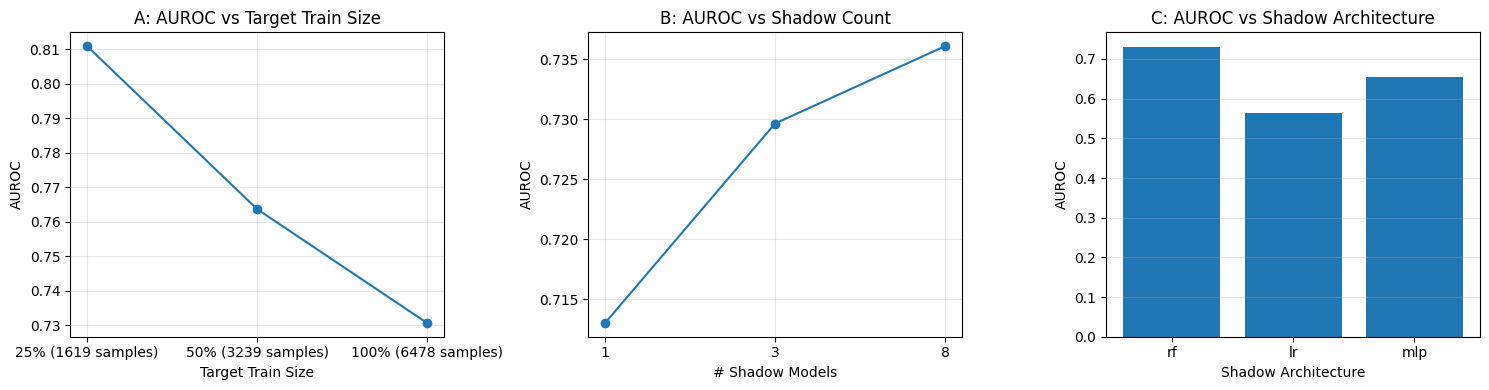

In [8]:
# Q3 - 3 different settings of MIA
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings("ignore")


def build_attack_features(probs, labels, num_classes):
    one_hot = np.eye(num_classes)[labels]
    return np.concatenate([probs, one_hot], axis=1)


def calc_precision_recall(predicted, actual, positive_value=1):
    score = 0
    num_positive_predicted = 0
    num_positive_actual = 0
    for i in range(len(predicted)):
        if predicted[i] == positive_value:
            num_positive_predicted += 1
        if actual[i] == positive_value:
            num_positive_actual += 1
        if predicted[i] == actual[i] and predicted[i] == positive_value:
            score += 1
    precision = 1 if num_positive_predicted == 0 else score / num_positive_predicted
    recall = 1 if num_positive_actual == 0 else score / num_positive_actual
    return precision, recall


def make_shadow_model(model_type, seed):
    if model_type == "rf":
        return RandomForestClassifier(random_state=seed)
    if model_type == "lr":
        return LogisticRegression(max_iter=400, random_state=seed)
    if model_type == "mlp":
        return MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=250, random_state=seed)
    raise ValueError(f"Unsupported shadow model type: {model_type}")


def run_shadow_mia(target_clf, x_member_eval, y_member_eval, x_nonmember_eval, y_nonmember_eval,
                   shadow_count=4, shadow_model_type="rf", seed=209):
    num_classes = len(np.unique(y_member_eval))

    # Use non-member pool as shadow
    x_shadow, y_shadow = x_nonmember_eval, y_nonmember_eval

    attack_X, attack_y = [], []
    for i in range(shadow_count):
        x_mem, x_non, y_mem, y_non = train_test_split(
            x_shadow,
            y_shadow,
            test_size=0.5,
            stratify=y_shadow,
            random_state=seed + i,
        )

        sm = make_shadow_model(shadow_model_type, seed + i)
        sm.fit(x_mem, y_mem)

        p_mem = sm.predict_proba(x_mem)
        p_non = sm.predict_proba(x_non)

        attack_X.append(build_attack_features(p_mem, y_mem, num_classes))
        attack_y.append(np.ones(len(x_mem), dtype=int))

        attack_X.append(build_attack_features(p_non, y_non, num_classes))
        attack_y.append(np.zeros(len(x_non), dtype=int))

    X_attack_train = np.vstack(attack_X)
    y_attack_train = np.concatenate(attack_y)

    attack_model = RandomForestClassifier(random_state=seed)
    attack_model.fit(X_attack_train, y_attack_train)

    p_member_eval = target_clf.predict_proba(x_member_eval)
    p_nonmember_eval = target_clf.predict_proba(x_nonmember_eval)

    X_member_eval = build_attack_features(p_member_eval, y_member_eval, num_classes)
    X_nonmember_eval = build_attack_features(p_nonmember_eval, y_nonmember_eval, num_classes)

    X_eval = np.vstack([X_member_eval, X_nonmember_eval])
    y_true = np.concatenate([
        np.ones(len(X_member_eval), dtype=int),
        np.zeros(len(X_nonmember_eval), dtype=int),
    ])

    y_pred = attack_model.predict(X_eval)
    y_prob = attack_model.predict_proba(X_eval)[:, 1]

    member_acc = np.mean(y_pred[:len(X_member_eval)] == 1)
    nonmember_acc = np.mean(y_pred[len(X_member_eval):] == 0)
    attack_acc = np.mean(y_pred == y_true)
    precision, recall = calc_precision_recall(y_pred, y_true)
    auroc = roc_auc_score(y_true, y_prob)

    return {
        "member_acc": member_acc,
        "nonmember_acc": nonmember_acc,
        "attack_acc": attack_acc,
        "precision": precision,
        "recall": recall,
        "auroc": auroc,
    }


# ------------------------------
# Setting A:Different target training set sizes
# Sizes: 25%, 50%, 100% of original training set
# ------------------------------
size_fractions = [0.25, 0.50, 1.00]
results_a = []

for frac in size_fractions:
    n = int(len(x_train) * frac)
    x_sub, y_sub = x_train[:n], y_train[:n]

    # Reuse Q1 model when fraction = 1.0
    if frac == 1.00:
        t_model = target_model
    else:
        t_model = RandomForestClassifier()
        t_model.fit(x_sub, y_sub)

    metrics = run_shadow_mia(
        target_clf=t_model,
        x_member_eval=x_sub,
        y_member_eval=y_sub,
        x_nonmember_eval=x_test,
        y_nonmember_eval=y_test,
        shadow_count=SHADOW_MODEL_COUNT,
        shadow_model_type="rf",
        seed=SEED,
    )
    results_a.append({
        "setting": "A_target_train_size",
        "config": f"{int(frac*100)}% ({n} samples)",
        **metrics,
    })


# ------------------------------
# Setting B: Different number of shadow models
# Number of shadow models: 1, 3, 8
# ------------------------------
shadow_counts = [1, 3, 8]
results_b = []

for n_shadow in shadow_counts:
    metrics = run_shadow_mia(
        target_clf=target_model,  # reuse Q1 target
        x_member_eval=x_train,
        y_member_eval=y_train,
        x_nonmember_eval=x_test,
        y_nonmember_eval=y_test,
        shadow_count=n_shadow,
        shadow_model_type="rf",
        seed=SEED,
    )
    results_b.append({
        "setting": "B_shadow_count",
        "config": f"{n_shadow}",
        **metrics,
    })


# ------------------------------
# Setting C: Differentshadow model architectures
# Architectures: Random Forest (rf), Logistic Regression (lr), MLP 
# ------------------------------
shadow_architectures = ["rf", "lr", "mlp"]
results_c = []

for arch in shadow_architectures:
    metrics = run_shadow_mia(
        target_clf=target_model,  # reuse Q1 target
        x_member_eval=x_train,
        y_member_eval=y_train,
        x_nonmember_eval=x_test,
        y_nonmember_eval=y_test,
        shadow_count=SHADOW_MODEL_COUNT,
        shadow_model_type=arch,
        seed=SEED,
    )
    results_c.append({
        "setting": "C_shadow_architecture",
        "config": arch,
        **metrics,
    })


# ------------------------------
# Comparison tables
# ------------------------------
df_a = pd.DataFrame(results_a)
df_b = pd.DataFrame(results_b)
df_c = pd.DataFrame(results_c)
df_all = pd.concat([df_a, df_b, df_c], ignore_index=True)

print("Setting A - Target Train Size")
display(df_a)
print("Setting B - Number of Shadow Models")
display(df_b)
print("Setting C - Shadow Model Architecture")
display(df_c)

print("Combined Comparison")
display(df_all)


# ------------------------------
# AUROC Plots
# ------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df_a["config"], df_a["auroc"], marker="o")
axes[0].set_title("A: AUROC vs Target Train Size")
axes[0].set_xlabel("Target Train Size")
axes[0].set_ylabel("AUROC")
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_b["config"], df_b["auroc"], marker="o")
axes[1].set_title("B: AUROC vs Shadow Count")
axes[1].set_xlabel("# Shadow Models")
axes[1].set_ylabel("AUROC")
axes[1].grid(True, alpha=0.3)

axes[2].bar(df_c["config"], df_c["auroc"])
axes[2].set_title("C: AUROC vs Shadow Architecture")
axes[2].set_xlabel("Shadow Architecture")
axes[2].set_ylabel("AUROC")
axes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



### **Q4.**
Draw a figure to explain the key components of the shadow model-based membership inference attack. Specifically, you are supposed to explain what the target model, the shadow model, the attack model, and what is the dataset used to train each of them (For example, you should clearly illustrate where each dataset comes from and how each dataset relates to the original dataset (e.g., the whole Nursery dataset) for experiments).

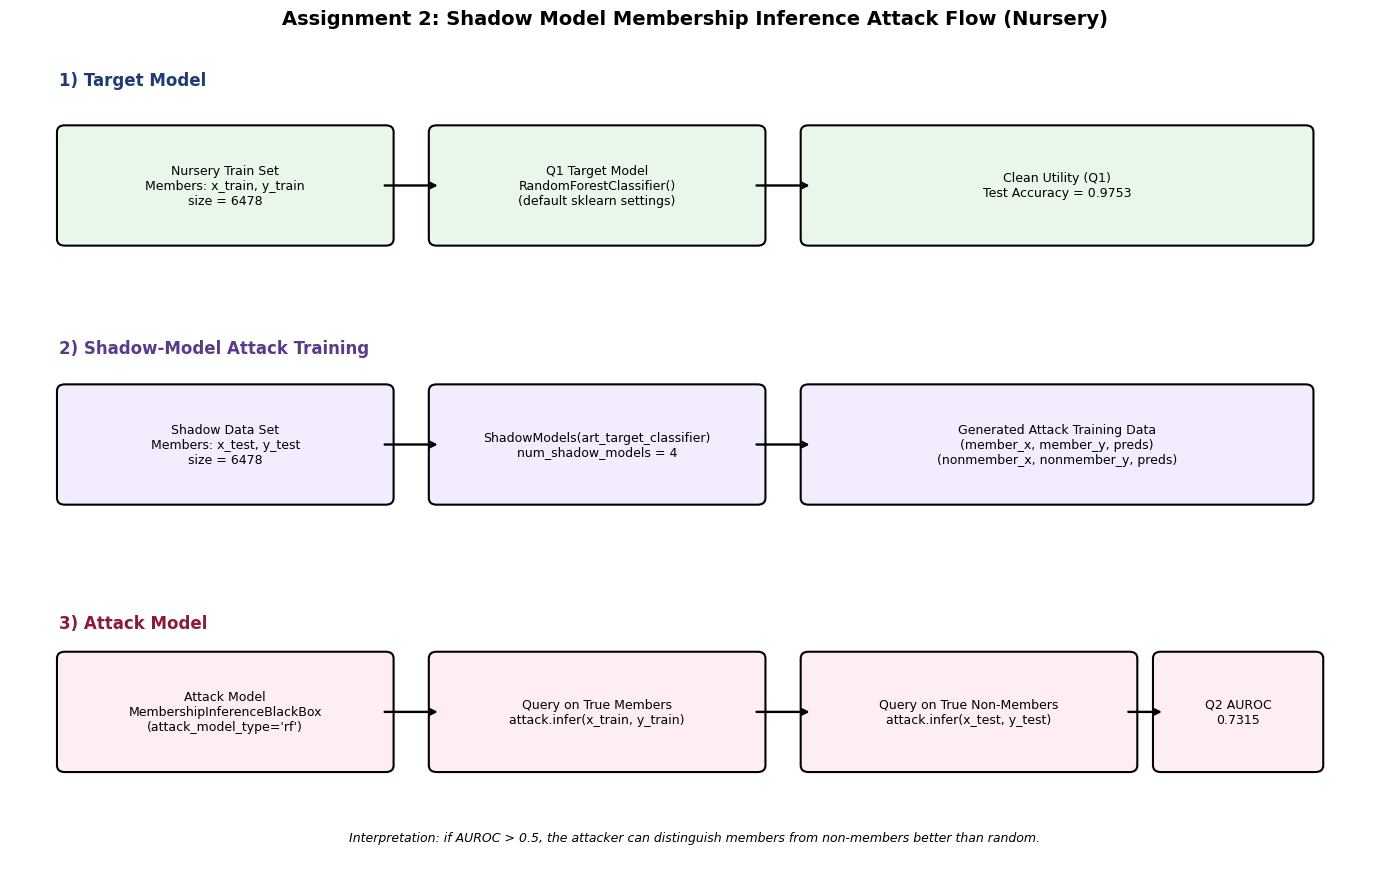

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Figure Explanation of Shadow Model MIA Flow
def draw_project_shadow_mia_flow():
    fig, ax = plt.subplots(figsize=(14, 9))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 10)
    ax.axis('off')

    def box(x, y, w, h, text, color):
        rect = patches.FancyBboxPatch(
            (x, y), w, h,
            boxstyle='round,pad=0.12,rounding_size=0.08',
            ec='black', fc=color, lw=1.5
        )
        ax.add_patch(rect)
        ax.text(x + w / 2, y + h / 2, text, ha='center', va='center', fontsize=9)

    train_n = len(x_train) if 'x_train' in globals() else 'N_train'
    test_n = len(x_test) if 'x_test' in globals() else 'N_test'
    shadow_count = SHADOW_MODEL_COUNT if 'SHADOW_MODEL_COUNT' in globals() else 'k'
    clean_acc = f"{target_test_acc:.4f}" if 'target_test_acc' in globals() else 'computed in Q1'
    q2_auroc = f"{auroc:.4f}" if 'auroc' in globals() else 'computed in Q2'

    ax.text(0.5, 9.5, '1) Target Model', fontsize=12, weight='bold', color='#1f3b73')
    ax.text(0.5, 6.3, '2) Shadow-Model Attack Training', fontsize=12, weight='bold', color='#5a3a8a')
    ax.text(0.5, 3.0, '3) Attack Model', fontsize=12, weight='bold', color='#8a1c35')

    box(0.6, 7.7, 3.2, 1.2, f'Nursery Train Set\nMembers: x_train, y_train\nsize = {train_n}', '#e8f7ea')
    box(4.4, 7.7, 3.2, 1.2, 'Q1 Target Model\nRandomForestClassifier()\n(default sklearn settings)', '#e8f7ea')
    box(8.2, 7.7, 5.0, 1.2, f'Clean Utility (Q1)\nTest Accuracy = {clean_acc}', '#e8f7ea')
    ax.annotate('', xy=(4.4, 8.3), xytext=(3.8, 8.3), arrowprops=dict(arrowstyle='->', lw=1.7))
    ax.annotate('', xy=(8.2, 8.3), xytext=(7.6, 8.3), arrowprops=dict(arrowstyle='->', lw=1.7))

    box(0.6, 4.6, 3.2, 1.2, f'Shadow Data Set\nMembers: x_test, y_test\nsize = {test_n}', '#f3ecff')
    box(4.4, 4.6, 3.2, 1.2, f'ShadowModels(art_target_classifier)\nnum_shadow_models = {shadow_count}', '#f3ecff')
    box(8.2, 4.6, 5.0, 1.2, 'Generated Attack Training Data\n(member_x, member_y, preds)\n(nonmember_x, nonmember_y, preds)', '#f3ecff')
    ax.annotate('', xy=(4.4, 5.2), xytext=(3.8, 5.2), arrowprops=dict(arrowstyle='->', lw=1.7))
    ax.annotate('', xy=(8.2, 5.2), xytext=(7.6, 5.2), arrowprops=dict(arrowstyle='->', lw=1.7))

    box(0.6, 1.4, 3.2, 1.2, "Attack Model\nMembershipInferenceBlackBox\n(attack_model_type='rf')", '#ffeef1')
    box(4.4, 1.4, 3.2, 1.2, 'Query on True Members\nattack.infer(x_train, y_train)', '#ffeef1')
    box(8.2, 1.4, 3.2, 1.2, 'Query on True Non-Members\nattack.infer(x_test, y_test)', '#ffeef1')
    box(11.8, 1.4, 1.5, 1.2, f'Q2 AUROC\n{q2_auroc}', '#ffeef1')
    ax.annotate('', xy=(4.4, 2.0), xytext=(3.8, 2.0), arrowprops=dict(arrowstyle='->', lw=1.7))
    ax.annotate('', xy=(8.2, 2.0), xytext=(7.6, 2.0), arrowprops=dict(arrowstyle='->', lw=1.7))
    ax.annotate('', xy=(11.8, 2.0), xytext=(11.4, 2.0), arrowprops=dict(arrowstyle='->', lw=1.7))

    ax.text(
        7.0, 0.5,
        'Interpretation: if AUROC > 0.5, the attacker can distinguish members from non-members better than random.',
        ha='center', va='center', fontsize=9, style='italic'
    )

    plt.title('Assignment 2: Shadow Model Membership Inference Attack Flow (Nursery)', fontsize=14, weight='bold', pad=14)
    plt.tight_layout()
    plt.show()


draw_project_shadow_mia_flow()



### Figure Explanation:
##### The diagram above shows a Shadow model-based MIA in this assignment.
- First, a target model is trained on the Nursery member set using RandomForestClassifier. The trained model demonstrated a clean test accuracy of ~97% to measure classification performance. 

- Once target model is developed, the attacker builds shadow models using a separate shadow data pool (the other 50% of the nursery data). These shadow models generate labeled attack-training examples and point to known member and non-members of each shadow model. Additionally the model outputs prediction and confidence patterns.

- Next, the attack model (MembershipInferenceBlackBox, RF-based) is trained on the shadow attack dataset. The model queries the real target model candidates and predicts whether each candidate was a true member or not.

- In this project, the attack AUROC was ~0.73 on average. An AUROC above 0.5 means that the attacker can successfully distinguish members from non-members better than random. From these results it can be seen that this attack was very successful.

##### Data used in the figure
- **Target model:** trained on `x_train, y_train` and tested on `x_test`, `y_test`
- **Shadow models:** trained on `x_shadow, y_shadow` to imitate target behavior and generate attack-training signals.
- **Attack dataset:** combines model outputs + true labels, labeled as member/non-member.
- **Attack model:** learns to predict whether a sample was in target training data or not
- **Evaluation:** reports member/non-member accuracy,  attack accuracy, precision, recall, and AUROC.


## **Part 2**

### **Q5** - 
What are the potential risks and countermeasures associated with membership inference attacks in machine learning systems?

### **Ans** - 
- **Risks**: A successfull MIA can result is large data breaches for companies such as sensitive personal information. This can lead to distrust in companies if client information is easily available to attackers via MIA. An important note is that machine learning systems do not currently inform their customers of the risks about overfitting information.
- **Countermeasures**: Controlled noise is the most effective way to mitigate MIA. This will inhibit the ability for a single data point to significantly change the models output. This can be accomplished by generating a model that only uses the largest *k* classes for prediction. If a model can avoid "overfitting" information, it will be less susceptable to MIA and will leak less information. Adding gauissin noise can aid in overcoming overfitting. L2 norm regularization techniques can penalize large parameters, thus making the defense against MIA stronger. 

### **Q6** - 
What are the potential risks and countermeasures associated with model stealing attacks in machine learning systems?
### **Ans** - 
- **Risks**: Model stealing is a cheap and quicker alternative to developing an original model. By querying a few thousand crafted entries a replica model can be produced with upwards of 80% accuracy. If a company is unable to prevent an attacker from replicating their model, they can lose their competitive advantage, even though they incurred all the costs for research and development. Additionally if an attacker were to replicate a model, they could potentially learn the vulnerabilities of their replica and then attack the original model. One of the other risks could include data leakage, similar to MIA which can be used to determine sensitive information included in the original model.
- **Countermeasures**: Limiting API tokens or tracking patterend queries from users can prohibit attackers from replicating robust models. This will limit a users ability to ask enough targeted questions to have a valid replica. Watermarking is an additional countermeasure, hidden imprints on data will enable a model to keep track of its own data if being used in a replica. One other countermeasure would be to weight model classes differently and keep sensitive information out of reach for unauthorized reasons. 

### **Documentation Statement**
#### The reference code provided in the assignment and located in /References was utilized heavily in creation of definitions and code development to create my own attack. Addtionally GitHub autopilot and the VSCode extension of Codex was utilized to recommend commands, troubleshoot, and edit comments for clarity. Code for the question 4 figure was autogenerated after typing the comment in the top of the cell (without any user prompting), the structure of the code was kept, but the information as to what each "bubble" says was edited to align with the project. Membership Inference Attacks Against Machine Learning Models by Shokri et Al. was provided in assignment material and referenced to understand the background on shadow model Membership Inference Attacks. 